# Preparation

In [1]:
import plotting as P
from config import create_config
import tables
from IPython.display import display

config = create_config()  
cache_dir = f"./cache_seed{config.seed}"
tables.save_config_table_tex(config=config, savepath="thesis/tables/config.tex")
tables.show_katex_array(tables.make_config_spec(config), caption="Problem Configuration")

<IPython.core.display.Latex object>

<div style='text-align:center; font-size:0.9em;'><b>Table.</b> Problem Configuration</div>

# Data Generation


Solving open loop OCPs...

 attempted |  solved   |  desired  
-----------------------------------


<IPython.core.display.Latex object>

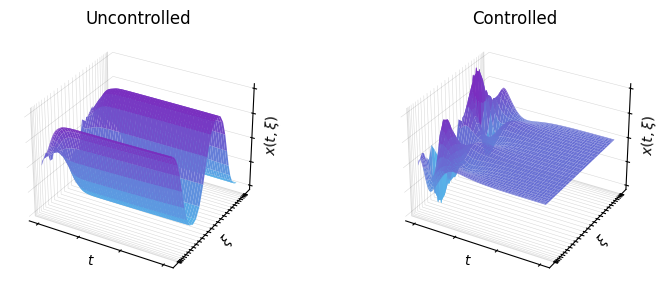

In [2]:
import matplotlib.pyplot as plt
from data import load_or_generate

data, meta = load_or_generate(config, n_trajectories=5, controller=config.ocp.LQR, force_regen=False)

tables.save_data_summary_table_tex(config=config, data=data, savepath="thesis/tables/data_summary.tex");
tables.show_katex_array(tables.make_data_summary_spec(config, data))

fig = P.plot_3d(config=config, controller=config.ocp.LQR, savepath="figures/test.pdf")
plt.show()

# Controller Training

In [3]:
from controls.train import train_or_load_gradnet, TrainConfig

cfg = TrainConfig(batch_size=config.n_states, grad_clip=1.0)

tables.save_traincfg_table_tex(train_cfg=cfg, savepath="thesis/tables/traincfg.tex")
tables.show_katex_array(tables.make_traincfg_spec(cfg), caption="Training configuration")

<IPython.core.display.Latex object>

<div style='text-align:center; font-size:0.9em;'><b>Table.</b> Training configuration</div>

In [ ]:
from controls.nn import Control

# Experimental: Residual Network
model0, _, hist0 = train_or_load_gradnet(config=config, kind="resnet", use_lqr=True, train_mode="hybrid", adaptive=True, supervision=False, train_cfg=cfg, data=data)
ctrl0 = Control(config, grad_net=model0)
# Model 1: Plain Supervised
#model1, _, hist1 = train_or_load_gradnet(config=config, kind="gradnet", use_lqr=True, train_mode="supervised", adaptive=False, supervision=False, train_cfg=cfg, data=data)
#ctrl1 = Control(config, grad_net=model1)

# Model 2: Hybrid
#model2, _, hist2 = train_or_load_gradnet(config=config, kind="gradnet", use_lqr=True, train_mode="hybrid", adaptive=False, supervision=False, train_cfg=cfg, data=data)
#ctrl2 = Control(config, grad_net=model2)

# Model 3: Adaptive Hybrid
model3, _, hist3 = train_or_load_gradnet(config=config, kind="gradnet", use_lqr=True, train_mode="hybrid", adaptive=True, supervision=False, train_cfg=cfg, data=data)
ctrl3 = Control(config, grad_net=model3)

# Model 4: Unsupervised with Supervised Penalty
#model4, _, hist4 = train_or_load_gradnet(config=config, kind="gradnet", use_lqr=True, train_mode="hybrid", adaptive=True, supervision=True, train_cfg=cfg, data=data)
#ctrl4 = Control(config, grad_net=model4)

# All loss curves in ONE plot, aligned on a shared timeline
# (supervised from 1..k, unsupervised from k..n)
P.plot_training_losses(
    series=[
     #   ("Model 1 (sup)", hist1),
        ("Model 0 (hybrid)", hist0),
        ("Model 3 (hybrid+adaptive)", hist3),
     #   ("Model 4 (unsup)", hist4),
    ],
    logy=True,
    smooth="ema",
    ema_alpha=0.03,
    savepath="figures/loss_curve_all.pdf",
);

epoch 0001 | loss=1.14e+00 | bs=32 | heur=nan
epoch 0002 | loss=1.05e-01 | bs=32 | heur=nan
epoch 0003 | loss=3.09e-02 | bs=32 | heur=nan
epoch 0001 | total=4.30e-02 | hjb=4.16e+03 | dpc=3.89e+01 | sup=0.00e+00 | bs=9 | heur=2.71e+02
epoch 0002 | total=4.25e-02 | hjb=3.60e+03 | dpc=3.89e+01 | sup=0.00e+00 | bs=10 | heur=1.60e+02
epoch 0003 | total=4.17e-02 | hjb=2.83e+03 | dpc=3.89e+01 | sup=0.00e+00 | bs=11 | heur=1.87e+02
epoch 0004 | total=4.00e-02 | hjb=1.51e+03 | dpc=3.85e+01 | sup=0.00e+00 | bs=12 | heur=3.86e+01
epoch 0005 | total=3.93e-02 | hjb=9.03e+02 | dpc=3.84e+01 | sup=0.00e+00 | bs=13 | heur=1.14e+02
epoch 0006 | total=3.92e-02 | hjb=6.88e+02 | dpc=3.85e+01 | sup=0.00e+00 | bs=14 | heur=1.72e+02
epoch 0007 | total=3.89e-02 | hjb=5.56e+02 | dpc=3.84e+01 | sup=0.00e+00 | bs=16 | heur=1.43e+02
epoch 0008 | total=3.85e-02 | hjb=5.16e+02 | dpc=3.80e+01 | sup=0.00e+00 | bs=18 | heur=1.44e+02
epoch 0009 | total=3.86e-02 | hjb=4.60e+02 | dpc=3.82e+01 | sup=0.00e+00 | bs=20 | heur

# Evaluation

In [ ]:
from evaluation import ic_hard, evaluate_controller
from sampling import sample_conditions

X_std = sample_conditions(config, n=10, seed=84)
X_hard = sample_conditions(config, n=10, seed=83, K=20, dist=6)

#X_hard, meta = ic_hard(config, n_pool=2, seed=7) # pool size can be adjusted

results = []
results += evaluate_controller(config, config.ocp.LQR, "LQR", X_std, X_hard)

results += evaluate_controller(config, ctrl0, "Model 0", X_std, X_hard)
results += evaluate_controller(config, ctrl3, "Model 3", X_std, X_hard)


controllers = [
    ("LQR (Baseline)", config.ocp.LQR),
    ("Model 0", ctrl0),
    ("Model 3", ctrl3),
]

all_metrics = []
for ctrl, name in controllers:
    all_metrics.extend(evaluate_controller(config, ctrl, name, X_std, X_hard))


tables.save_results_table_tex(results=results, savepath="thesis/tables/controllers.tex")

tables.show_katex_array(tables.make_results_spec_2row(results, controller="LQR"), caption="LQR")
tables.show_katex_array(tables.make_results_spec_2row(results, controller="Model 0"), caption="Model 0")
tables.show_katex_array(tables.make_results_spec_2row(results, controller="Model 3"), caption="Model 3")

<IPython.core.display.Latex object>

<div style='text-align:center; font-size:0.9em;'><b>Table.</b> LQR</div>

<IPython.core.display.Latex object>

<div style='text-align:center; font-size:0.9em;'><b>Table.</b> Model 0</div>

<IPython.core.display.Latex object>

<div style='text-align:center; font-size:0.9em;'><b>Table.</b> Model 3</div>

## Plots

In [ ]:
#P.set_thesis_style()
KW = dict(config=config, controller=ctrl2, seed=0)

NameError: name 'ctrl2' is not defined

### Value Function

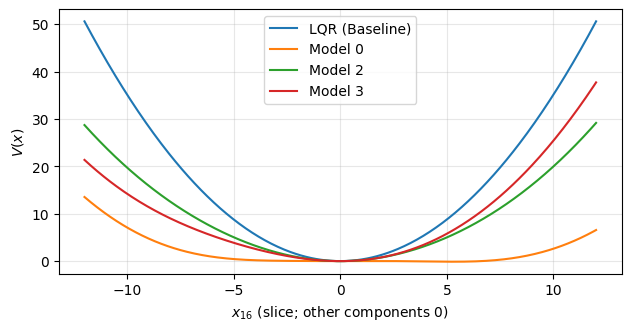

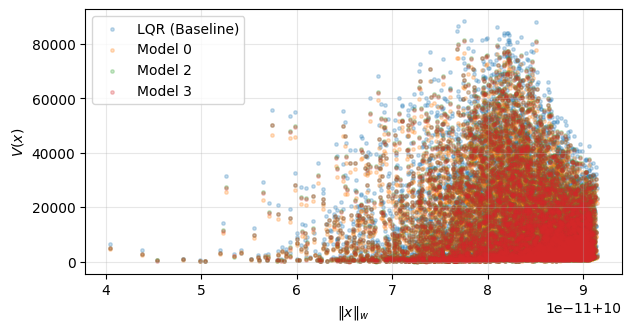

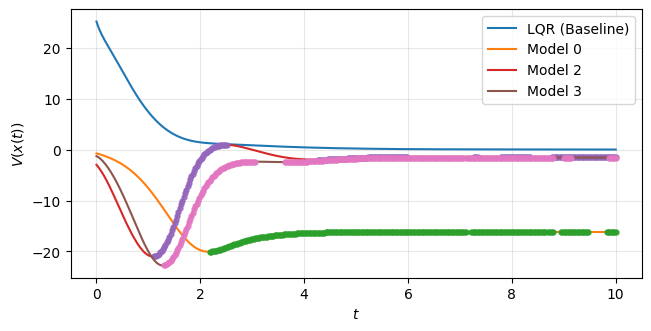

In [ ]:
P.plot_value_slice(config=config, controllers=controllers, i=0.5*config.n_states, savepath="figures/V_slice.pdf")
P.plot_value_vs_state_norm(config=config, controllers=controllers, n=8000, savepath="figures/V_vs_norm.pdf", dist=10)
P.plot_value_flow(config=config, controllers=controllers, seed=0, tspan=(0.0, 10.0), Nt=400, savepath="figures/V_flow.pdf");

plt.show()

### Value Gradient

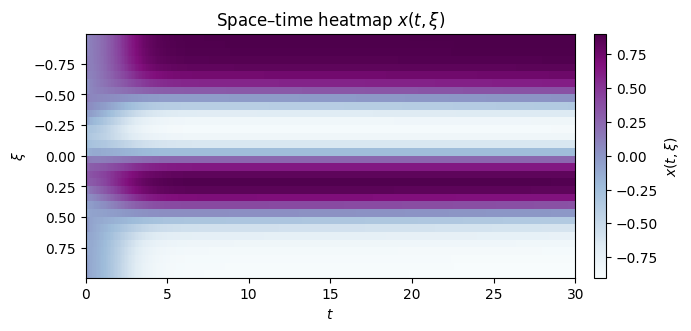

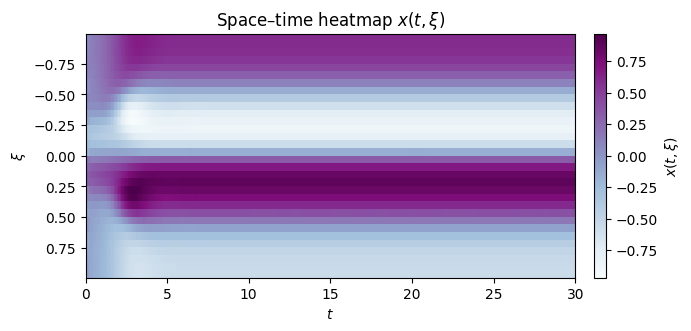

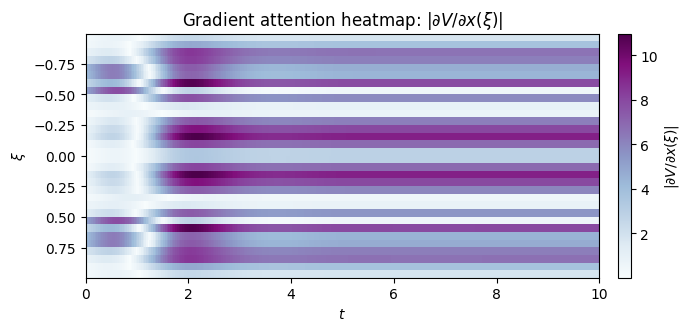

In [ ]:
P.plot_space_time_heatmap(config=config, controller=P._ZeroController(config), seed=0, tspan=(0.0, 30.0), savepath="figures/heatmap_uncontrolled.pdf");
P.plot_space_time_heatmap(config=config, controller=ctrl0, seed=0, tspan=(0.0, 30.0), savepath="figures/heatmap_ctrl0.pdf");
P.plot_gradient_attention_heatmap(config=config, controller=ctrl3, seed=0, tspan=(0.0, 10.0), Nt=300, savepath="figures/attention_ctrl3.pdf");

### HJB-Residual

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x3 and 32x3)

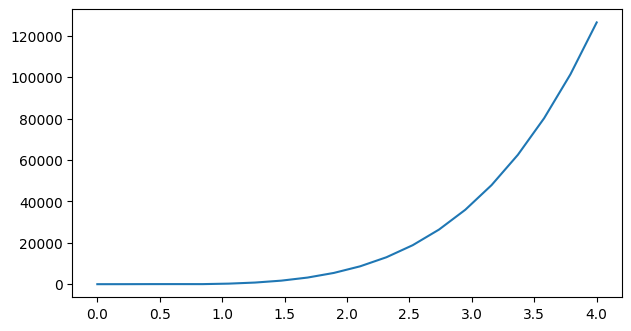

In [ ]:
P.plot_hjb_residual_shock_line(config=config, controllers=controllers, savepath="figures/hjb_truth_line.pdf");